# -> mein Code unter Theorie-Teil und FFT-Funktionen

NB: Below I use numpy.fft with an odd extension of my input signal. One can implement the discrete sine transform faster without the odd extension; this is done in scipy.fft.dst


# Sine-series coefficients of $x(s)$ on $(0,\pi)$ via FFT (forward + inverse)
**Course 02624**
*(Kim Knudsen, 2026)*


We want the coefficients $\hat x(j)$ of the sine expansion

$$x(s) \;\sim\; \sum_{j=1}^{N-1} \hat x(j) \sin(js), \qquad s \in (0,\pi),$$

where, in the continuous limit,

$$\hat x(j) = \frac{2}{\pi}\int_0^{\pi} x(s)\,\sin(js)\,ds .$$

**Setup.** $x$ is sampled at $N-1$ equidistant interior points

$$s_k = \frac{k\pi}{N}, \qquad k = 1,\dots,N-1$$


**Forward transform (samples $\to$ coefficients).** Extend the samples to an
*odd*, $2\pi$-periodic sequence of length $2N$,

$$v_0 = 0,\quad v_k = x_k\ (k=1,\dots,N-1),\quad v_N = 0,\quad v_{2N-k} = -x_k\ (k=1,\dots,N-1),$$

and take $V = \mathrm{FFT}(v)$. Because $v$ is real and odd, $V$ is purely
imaginary, and

$$\boxed{\,b_j = -\frac{1}{N}\,\mathrm{Im}(V_j), \qquad j = 1,\dots,N-1\,}$$

is exactly the (trapezoidal-rule) discrete sine transform (DST-I) — indexed
so that `b[j-1]` multiplies $\sin(js)$.

**Inverse transform (coefficients $\to$ samples).** Since $v$ real & odd
$\Rightarrow$ $V_j = -iN b_j$ and $V_{2N-j} = -V_j$ (with $V_0=V_N=0$), we can
rebuild the full spectrum $V$ from $\{b_j\}$ and invert with an ordinary
inverse FFT:

$$V_j = -iN b_j,\qquad V_{2N-j} = iN b_j \qquad (j=1,\dots,N-1),$$
$$v = \mathrm{IFFT}(V) \quad\Longrightarrow\quad x_k = \mathrm{Re}(v_k),\ k=1,\dots,N-1.$$

Both directions cost $O(N\log N)$ (vs. $O(N^2)$ for direct quadrature /
direct summation of the sine series).


In [91]:
import numpy as np
np.set_printoptions(threshold=np.inf)

import matplotlib.pyplot as plt
from math import exp, sin

## Grid, forward transform, inverse transform

In [92]:
def sine_grid(N):
    """
    Equidistant interior grid s_k = k*pi/N, k = 1, ..., N-1, on (0, pi).
    N - 1 is the number of samples / modes.
    """
    k = np.arange(1, N)
    return k * np.pi / N


def sine_coeffs_from_samples(xk):
    """
    Forward transform (samples -> sine coefficients), via FFT.

    xk : array_like, shape (N-1,)
        Samples x_k = x(s_k) at the equidistant interior points
        s_k = k*pi/N, k = 1, ..., N-1. N is inferred as len(xk) + 1.

    Returns
    -------
    j : ndarray, shape (N-1,)
        Mode indices j = 1, ..., N-1 (j <-> coefficient of sin(j*s)).
    b : ndarray, shape (N-1,)
        Sine coefficients such that x(s_k) ~ sum_j b_j * sin(j * s_k).
    """
    xk = np.asarray(xk, dtype=float)
    M = len(xk)
    N = M + 1

    # odd, 2*pi-periodic extension on a length-2N grid
    v = np.zeros(2 * N)
    v[1:N] = xk
    v[N + 1:2 * N] = -xk[::-1]
    # v[0] = v[N] = 0 by construction (Dirichlet endpoints)

    V = np.fft.fft(v)       #have mirrored our sampling points -> now we can apply classic FFT
    j = np.arange(1, N)     
    b = -V.imag[1:N] / N    # takes imaginary-part of V of 1-N, division with N to normalize
    return j, b


def samples_from_sine_coeffs(b):
    """
    Inverse transform (sine coefficients -> samples), via inverse FFT.

    b : array_like, shape (N-1,)
        Sine coefficients b_j, j = 1, ..., N-1 (N = len(b) + 1).

    Returns
    -------
    xk : ndarray, shape (N-1,)
        Recovered samples x_k = x(s_k) at s_k = k*pi/N, k = 1, ..., N-1.
    """
    b = np.asarray(b, dtype=float)
    M = len(b)
    N = M + 1
    j = np.arange(1, N)

    V = np.zeros(2 * N, dtype=complex)
    V[j] = -1j * N * b
    V[2 * N - j] = 1j * N * b
    # V[0] = V[N] = 0

    v = np.fft.ifft(V)
    return v[1:N].real


## Example

Define your own $x(s)$ here; the example below is $x(s) = s(\pi-s)e^{s}$.

In [93]:
def x(s):
    return s * (np.pi - s) * np.exp(s)

N = 128                    # N - 1 samples/modes
s_grid = sine_grid(N)       # stützstellen
xk = x(s_grid)              # x ausgewertet an stützstellen
j, b = sine_coeffs_from_samples(xk)     # bekommt stützstellenwerte, liefert fourierkoeffizienten
# print("First 10 coefficients b_j:")
# for jj, bj in list(zip(j, b))[:10]:
#     print(f"  j={jj:2d}   b_j = {bj: .6f}")

In [99]:
# now we want to calc the fourier-sum
T = 0.5

Kx_s = np.zeros(len(xk))
for k,s_k in enumerate(s_grid):
    Kx_s[k] = sum( exp(-T*jj**2) * sin(jj*s_k) * bj     for jj, bj in list(zip(j, b)) )    # g(x) = Kf(x)          bzw. u(x,T) = Ku(x,0) = Ku_0(x)

# want to calc matrix A 
"""
Matrix A:
y = Ax
therefore:
A = S @ D @ S_T
with 
- S[k,j] = sin(j*s_k)
- D = diag( exp(-j²*T) for j=1,...N)


"""
print(len(j))
# --- calc b by matrix-multiplication:
S = np.zeros((N-1,N-1))
for k in range(N-1):
    for i in range(N-1):
        S[k,i] = sin(j[i]*s_grid[k])
# S_T = np.linalg.matrix_transpose(S)

D = np.diag([exp(-i**2 * T) for i in j])

A = S @ D @ (2/N * S.T)     # S_T @ xk = bk are the fourier-koefficients

yk = A @ xk

127


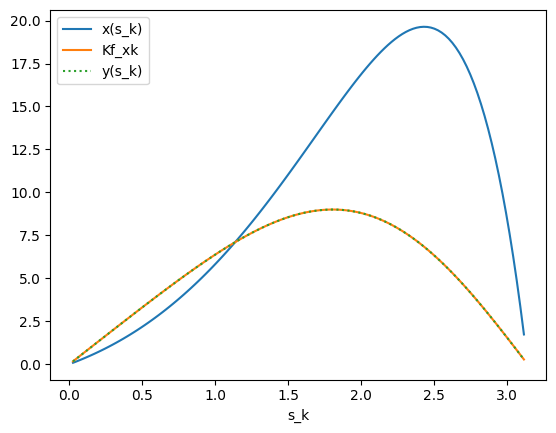

3.552713678800501e-15


In [100]:
import matplotlib.pyplot as plt
plt.plot(s_grid,xk,label="x(s_k)")
plt.plot(s_grid,Kx_s,label="Kf_xk")
plt.plot(s_grid,yk,label="y(s_k)",linestyle="dotted")
plt.legend()
plt.xlabel("s_k")
plt.show()

print(np.max(np.abs(Kx_s - yk)))

## Round trip: samples $\to$ coefficients $\to$ samples

The inverse FFT transform should recover the original samples to machine
precision, since forward and inverse are exact adjoint FFT operations on the
same $2N$-point grid (no truncation involved here — every mode is kept).

In [96]:
# tests FFT - if we can recalculate our sampling points from our sine-coefficients

xk_rec = samples_from_sine_coeffs(b)
print("max |x_k - IFFT(FFT(x_k))| =", np.max(np.abs(xk - xk_rec)))


max |x_k - IFFT(FFT(x_k))| = 6.217248937900877e-15
